# 1. SETUP DE ENTORNO (CRISP-DM: Preparación)

In [1]:

import os
import sys
# Clonar el repositorio oficial de MindLab si no existe
if not os.path.exists('/content/kdm'):
    !git clone https://github.com/fagonzalezo/kdm.git

# Instalar el paquete kdm en modo desarrollo
!pip install -q -e /content/kdm

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
import time

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,  classification_report


print(f"TensorFlow Version: {tf.__version__}")
print("Entorno KDM configurado exitosamente.")

Cloning into 'kdm'...
remote: Enumerating objects: 558, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 558 (delta 33), reused 36 (delta 26), pack-reused 502 (from 1)
Receiving objects: 100% (558/558), 61.81 MiB | 13.43 MiB/s, done.
Resolving deltas: 100% (328/328), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for kdm (pyproject.toml) ... done
TensorFlow Version: 2.19.0
Entorno KDM configurado exitosamente.


In [2]:
sys.path.append('/content/kdm')

# Crear estructura de carpetas para la tesis
os.makedirs('resultados/modelos', exist_ok=True)
os.makedirs('resultados/metricas', exist_ok=True)

print("Rutas configuradas y directorios creados.")

Rutas configuradas y directorios creados.


In [3]:

from kdm.models.kdm_class_model import KDMClassModel
from kdm.layers.rbf_kernel_layer import RBFKernelLayer
from tensorflow.keras import layers, Sequential

/content/kdm/kdm/utils.py:186: SyntaxWarning: invalid escape sequence '\p'
  Calculates the overlap of a state  \phi(x) with a density


# 2. DATA PIPELINE (CRISP-DM: Data Preparation)

In [4]:
# ==========================================
# BLOQUE 1: Configuración de Datos Fashion-MNIST y K-Fold (KDM)
# ==========================================
import numpy as np
from sklearn.model_selection import KFold
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

class KDMDataPipelineFashionKFold:
    def __init__(self, data_dir='./data'):
        # Mantienes el rango [0, 1] esencial para la estabilidad del Kernel RBF en KDM
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: torch.flatten(x))
        ])
        self.data_dir = data_dir

        # Etiquetas oficiales de Fashion-MNIST
        self.class_names = [
            'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
            'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
        ]

    def load_full_numpy_datasets(self):
        """
        Carga los datasets en memoria y los convierte a tensores de NumPy
        en una sola operación vectorial (sin iteración manual por lotes).
        """
        train_set = datasets.FashionMNIST(self.data_dir, train=True, download=True, transform=self.transform)
        test_set = datasets.FashionMNIST(self.data_dir, train=False, download=True, transform=self.transform)

        # Usar el tamaño total del dataset como batch_size para extracción masiva
        train_loader = DataLoader(train_set, batch_size=len(train_set), shuffle=False)
        test_loader = DataLoader(test_set, batch_size=len(test_set), shuffle=False)

        x_train, y_train = next(iter(train_loader))
        x_test, y_test = next(iter(test_loader))

        return x_train.numpy(), y_train.numpy(), x_test.numpy(), y_test.numpy()

# --- INICIALIZACIÓN DEL ESPACIO DE TRABAJO ---
pipeline_kdm_fashion = KDMDataPipelineFashionKFold()
x_train_full, y_train_full, x_test_final, y_test_final = pipeline_kdm_fashion.load_full_numpy_datasets()

# Instanciamos el K-Fold garantizando la misma semilla (random_state=42)
# que usamos en todos los experimentos anteriores.
K_FOLDS = 5
kf_kdm = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

print(f"--- FASHION-MNIST PREPARADO PARA KDM (K-FOLD) ---")
print(f"Dataset de entrenamiento total (X): {x_train_full.shape} - (Muestras, Características aplanadas)")
print(f"Dataset de entrenamiento total (Y): {y_train_full.shape}")
print(f"Dataset de prueba (Test) reservado: {x_test_final.shape}")
print(f"Ejemplo de categorías: {pipeline_kdm_fashion.class_names[:3]}...")

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 328kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.52MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.2MB/s]


--- FASHION-MNIST PREPARADO PARA KDM (K-FOLD) ---
Dataset de entrenamiento total (X): (60000, 784) - (Muestras, Características aplanadas)
Dataset de entrenamiento total (Y): (60000,)
Dataset de prueba (Test) reservado: (10000, 784)
Ejemplo de categorías: ['T-shirt/top', 'Trouser', 'Pullover']...


# 3. MODELADO KDM (CRISP-DM: Modeling)

In [5]:
# ==========================================
# BLOQUE 2: Espacio de Búsqueda (Grid Search) e Instanciación KDM Fashion-MNIST
# ==========================================
import itertools
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
import numpy as np

# 1. DEFINICIÓN DEL ESPACIO DE BÚSQUEDA KDM (Adaptado para Fashion-MNIST)
param_grid_kdm_fashion = {
    'n_comp': [256, 512],        # Número de anclas en el RKHS (Densidad)
    'encoded_size': [128, 256],  # <-- CAPACIDAD AUMENTADA: Espacio latente más robusto para ropa
    'lr': [1e-3, 5e-4]           # Tasa de aprendizaje
}

# Generar el producto cartesiano de todas las combinaciones
keys, values = zip(*param_grid_kdm_fashion.items())
grid_configs_kdm_fashion = [dict(zip(keys, v)) for v in itertools.product(*values)]

print("--- ESPACIO DE BÚSQUEDA DE HIPERPARÁMETROS (KDM FASHION-MNIST) ---")
print(f"Total de arquitecturas KDM a evaluar: {len(grid_configs_kdm_fashion)}")
for i, config in enumerate(grid_configs_kdm_fashion):
    print(f" Config {i+1}: N_Comp={config['n_comp']}, Encoded_Size={config['encoded_size']}, LR={config['lr']}")

# ==========================================
# 2. FUNCIÓN DE INSTANCIACIÓN DINÁMICA (FACTORY KDM FASHION)
# ==========================================
def crear_modelo_kdm_fashion(config, x_train_fold, y_train_fold):
    """
    Instancia el Encoder y el clasificador KDM desde cero, garantizando
    que no haya fuga de pesos entre Folds.
    """
    # 2.1 Construir el Feature Encoder con mayor capacidad latente
    encoder = Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu'), # Capa oculta ligeramente más ancha para procesar texturas
        layers.Dense(config['encoded_size'], activation='relu')
    ], name="kdm_encoder_fashion")

    # 2.2 Instanciar el KDM Classifier
    modelo_kdm = KDMClassModel(
        encoded_size=config['encoded_size'],
        dim_y=10, # 10 clases de Fashion-MNIST
        encoder=encoder,
        n_comp=config['n_comp'],
        sigma=0.5, # Inicial por defecto
        sigma_trainable=True
    )

    modelo_kdm.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config['lr']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 2.3 Inicialización Topológica Estricta (Solo con datos del Fold actual)
    samples_x = x_train_fold[:config['n_comp']]
    samples_y_sparse = y_train_fold[:config['n_comp']]

    # Convertir a One-Hot para la Matriz de Densidad
    samples_y_onehot = keras.utils.to_categorical(samples_y_sparse, num_classes=10)

    # Inicializar componentes y estimar Sigma basado en las anclas del fold
    modelo_kdm.init_components(samples_x, samples_y_onehot, init_sigma=True)

    # 2.4 Calcular parámetros entrenables totales
    total_params = np.sum([keras.backend.count_params(w) for w in modelo_kdm.trainable_weights])

    return modelo_kdm, total_params

# --- PRUEBA AISLADA DE LA FÁBRICA ---
# Usamos un subconjunto seguro para verificar que compila correctamente
x_prueba_aislada = x_train_full[:1000]
y_prueba_aislada = y_train_full[:1000]

mod_kdm_prueba, params_kdm_prueba = crear_modelo_kdm_fashion(grid_configs_kdm_fashion[0], x_prueba_aislada, y_prueba_aislada)
print(f"\n[Verificación Exitosa] Modelo KDM Fashion instanciado.")
print(f"Sigma estimado inicial: {mod_kdm_prueba.kernel.sigma.numpy():.4f}")
print(f"Total de parámetros entrenables: {params_kdm_prueba:,}")

--- ESPACIO DE BÚSQUEDA DE HIPERPARÁMETROS (KDM FASHION-MNIST) ---
Total de arquitecturas KDM a evaluar: 8
 Config 1: N_Comp=256, Encoded_Size=128, LR=0.001
 Config 2: N_Comp=256, Encoded_Size=128, LR=0.0005
 Config 3: N_Comp=256, Encoded_Size=256, LR=0.001
 Config 4: N_Comp=256, Encoded_Size=256, LR=0.0005
 Config 5: N_Comp=512, Encoded_Size=128, LR=0.001
 Config 6: N_Comp=512, Encoded_Size=128, LR=0.0005
 Config 7: N_Comp=512, Encoded_Size=256, LR=0.001
 Config 8: N_Comp=512, Encoded_Size=256, LR=0.0005
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step 

[Verificación Exitosa] Modelo KDM Fashion instanciado.
Sigma estimado inicial: 1.3802
Total de parámetros entrenables: 503,169.0


# 4. ENTRENAMIENTO Y EVALUACIÓN (CRISP-DM: Evaluation)

In [6]:
# ==========================================
# BLOQUE 3: Bucle Principal KDM Fashion-MNIST con Registro "Tidy"
# ==========================================
import time
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras

# Asegurar que existan las rutas
os.makedirs('/content/resultados/modelos', exist_ok=True)
os.makedirs('/content/resultados/metricas', exist_ok=True)

EPOCHS = 10
BATCH_SIZE = 128

# Callback para capturar los tiempos de Keras (Tu excelente implementación)
class TimeHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.times = []
    def on_epoch_begin(self, batch, logs={}):
        self.epoch_time_start = time.time()
    def on_epoch_end(self, batch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)

# Variables globales para el registro
historial_global_kdm_fashion = []
mejor_accuracy_global_kdm = 0.0
mejor_config_global_kdm = None
ruta_mejor_modelo_kdm = '/content/resultados/modelos/mejor_kdm_fashion_pesos.weights.h5'

print("\n--- INICIANDO ENTRENAMIENTO KDM FASHION-MNIST (GRID SEARCH + K-FOLD) ---")

for idx_config, config in enumerate(grid_configs_kdm_fashion):
    print(f"\n[{idx_config+1}/{len(grid_configs_kdm_fashion)}] Config: N_Comp={config['n_comp']}, Encoded_Size={config['encoded_size']}, LR={config['lr']}")

    # K-Fold sobre los índices del conjunto de entrenamiento total
    for fold, (train_idx, val_idx) in enumerate(kf_kdm.split(x_train_full)):
        print(f"  -> Iniciando Fold {fold + 1}/{K_FOLDS}...")

        # 1. Slicing vectorial de NumPy para extraer el Fold actual
        x_train_fold, y_train_fold = x_train_full[train_idx], y_train_full[train_idx]
        x_val_fold, y_val_fold = x_train_full[val_idx], y_train_full[val_idx]

        # 2. Instanciar KDM Fashion y realizar Inicialización Topológica
        modelo_kdm, total_params = crear_modelo_kdm_fashion(config, x_train_fold, y_train_fold)

        # 3. Preparar el Callback de tiempo
        time_callback = TimeHistory()

        # 4. Entrenamiento del Fold (verbose=0 para consola limpia)
        history = modelo_kdm.fit(
            x_train_fold, y_train_fold,
            validation_data=(x_val_fold, y_val_fold),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[time_callback],
            verbose=0
        )

        # 5. Volcado de la historia al formato Tidy para la Tesis
        for ep in range(EPOCHS):
            val_acc = history.history['val_accuracy'][ep]

            registro_epoca = {
                'config_id': idx_config + 1,
                'n_comp': config['n_comp'],
                'encoded_size': config['encoded_size'],
                'lr': config['lr'],
                'fold': fold + 1,
                'epoch': ep + 1,
                'train_loss': history.history['loss'][ep],
                'train_acc': history.history['accuracy'][ep],
                'val_loss': history.history['val_loss'][ep],
                'val_acc': val_acc,
                'epoch_time_seconds': time_callback.times[ep],
                'total_params': total_params
            }
            historial_global_kdm_fashion.append(registro_epoca)

            # Lógica para capturar el mejor modelo absoluto
            if val_acc > mejor_accuracy_global_kdm:
                mejor_accuracy_global_kdm = val_acc
                mejor_config_global_kdm = config
                modelo_kdm.save_weights(ruta_mejor_modelo_kdm)
                epoca_campeona = ep + 1

        acc_final_fold = history.history['val_accuracy'][-1]
        tiempo_total_fold = sum(time_callback.times)
        print(f"     Fin Fold {fold+1} | Val Acc: {acc_final_fold:.4f} | Tiempo Total: {tiempo_total_fold:.1f}s")

    if 'epoca_campeona' in locals() and mejor_config_global_kdm == config:
        print(f"     [!] NUEVO CAMPEÓN: Guardando pesos (Val Acc: {mejor_accuracy_global_kdm:.4f}) en Época {epoca_campeona}")

# ==========================================
# 6. EXPORTACIÓN PARA EL NOTEBOOK DE ANÁLISIS
# ==========================================
df_kdm_fashion = pd.DataFrame(historial_global_kdm_fashion)
ruta_csv_export = '/content/resultados/metricas/kdm_kfold_fashion_history.csv'
df_kdm_fashion.to_csv(ruta_csv_export, index=False)

print("\n=======================================================")
print(f"ENTRENAMIENTO KDM FASHION-MNIST FINALIZADO.")
print(f"Resultados exportados a: '{ruta_csv_export}'")
print(f"Mejor Configuración: {mejor_config_global_kdm}")
print(f"Mejor Exactitud (Validation): {mejor_accuracy_global_kdm:.4f}")
print("=======================================================")


--- INICIANDO ENTRENAMIENTO KDM FASHION-MNIST (GRID SEARCH + K-FOLD) ---

[1/8] Config: N_Comp=256, Encoded_Size=128, LR=0.001
  -> Iniciando Fold 1/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
     Fin Fold 1 | Val Acc: 0.8777 | Tiempo Total: 157.0s
  -> Iniciando Fold 2/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
     Fin Fold 2 | Val Acc: 0.8802 | Tiempo Total: 138.4s
  -> Iniciando Fold 3/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
     Fin Fold 3 | Val Acc: 0.8955 | Tiempo Total: 146.4s
  -> Iniciando Fold 4/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
     Fin Fold 4 | Val Acc: 0.8928 | Tiempo Total: 130.1s
  -> Iniciando Fold 5/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
     Fin Fold 5 | Val Acc: 0.8907 | Tiempo Total: 155.1s
     [!] NUEVO CAMPEÓN: Guardando pesos (Val Acc: 0.8955) en Época 10

[2/8] Config: N_Comp=256, Encoded_Size=128, LR=0.0005
  -> Iniciando Fold 1/5...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
     Fin Fold 1 | Val Acc: 0.8877 | Tiempo Total: 158.1s
  -> Iniciando 

Generando predicciones de KDM para Fashion-MNIST...


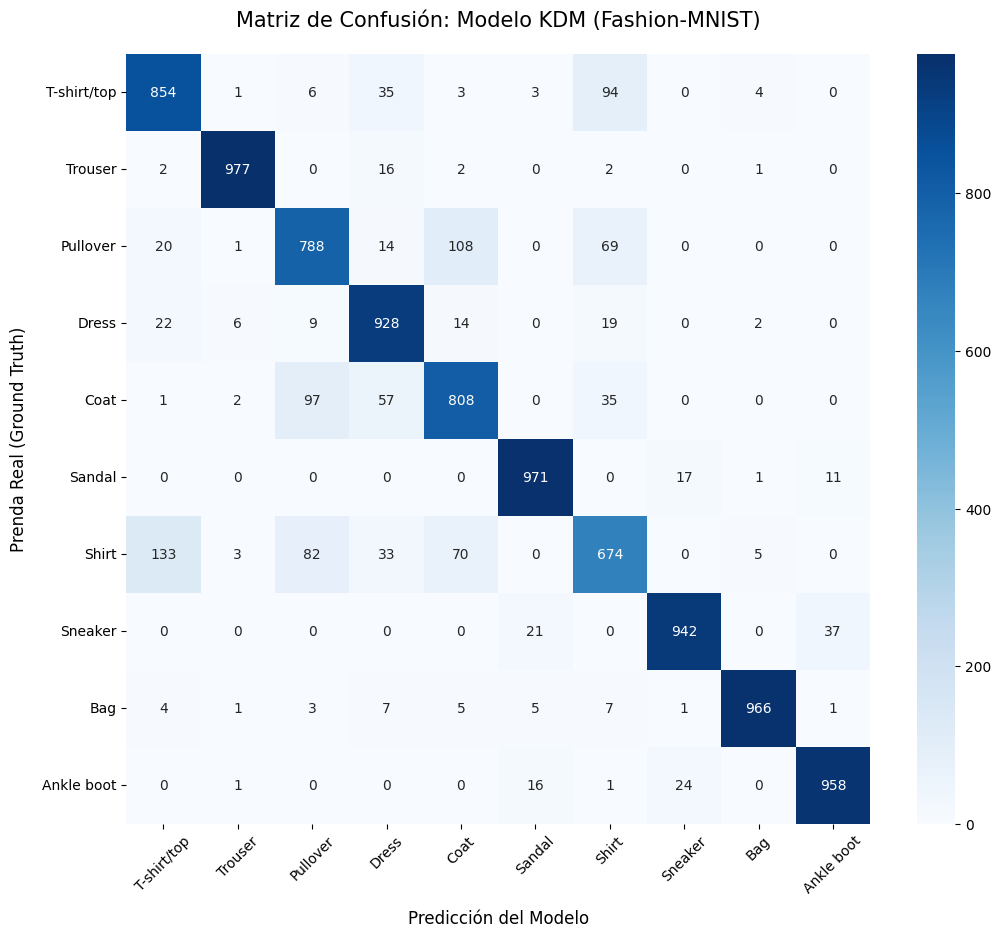

Matriz de Fashion-MNIST guardada en: /content/resultados/matriz_confusion_kdm_fashion.png


In [ ]:

# ANÁLISIS DE ERRORES: MATRIZ DE CONFUSIÓN (FASHION-MNIST)


# 1. Definir los nombres reales de las prendas
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("Generando predicciones de KDM para Fashion-MNIST...")
# Asegúrate de que x_test sea el de Fashion-MNIST (aplanado 784)
y_pred_probs = modelo_kdm.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Calcular la matriz
cm = confusion_matrix(y_test, y_pred)

# 3. Graficar con etiquetas de texto
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=class_names, yticklabels=class_names)

plt.title('Matriz de Confusión: Modelo KDM (Fashion-MNIST)', fontsize=15, pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12, labelpad=10)
plt.ylabel('Prenda Real (Ground Truth)', fontsize=12, labelpad=10)

# Rotar las etiquetas para que se lean bien
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Guardar con nombre específico para evitar sobrescribir MNIST
ruta_cm = '/content/resultados/matriz_confusion_kdm_fashion.png'
plt.savefig(ruta_cm, dpi=300, bbox_inches='tight')
plt.show()

print(f"Matriz de Fashion-MNIST guardada en: {ruta_cm}")

In [ ]:

report_kdm = classification_report(y_test, y_pred, output_dict=True)
#report_pnc = classification_report(todas_las_etiquetas, todas_las_preds, output_dict=True)

# 2. Extraer métricas globales (Weighted Avg)
data = {
    'Métrica': ['Precision', 'Recall', 'F1-Score', 'Accuracy'],
    'KDM (Inspiración Cuántica)': [
        report_kdm['weighted avg']['precision'],
        report_kdm['weighted avg']['recall'],
        report_kdm['weighted avg']['f1-score'],
        report_kdm['accuracy']
    ]

}


df_comparativo = pd.DataFrame(data)
print("--- TABLA COMPARATIVA DE RENDIMIENTO FINAL ---")
print(df_comparativo.to_string(index=False))

df_comparativo.to_csv('/content/resultados/tabla_comparativa_final.csv', index=False)

--- TABLA COMPARATIVA DE RENDIMIENTO FINAL ---
  Métrica  KDM (Inspiración Cuántica)
Precision                    0.885972
   Recall                    0.886600
 F1-Score                    0.885870
 Accuracy                    0.886600
